# Portfolio Metrics

In [221]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date, timedelta
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import contextlib
import io
from copulae import GaussianCopula, StudentCopula
from scipy.stats import t as student_t, norm, laplace, genextreme

In [222]:
q = {
    "DFAI":43, 
    "META":2, 
    "MSFT":3, 
    "JPM":4, 
    "SPY":42, 
}

tickers = list(q.keys())

years = 7
end_date = date.today()
start_date = end_date - timedelta(days=years * 365)

In [223]:
def get_daily_bars(symbols, start_date, end_date):
    """
    Fetch daily OHLCV data from Yahoo Finance using yfinance.

    Returns:
        data: long DataFrame with columns:
              symbol, open, high, low, close, adj_close, volume
        close_prices: wide DataFrame of close prices by symbol
    """

    raw = yf.download(
        tickers=symbols,
        start=start_date.isoformat(),
        end=end_date.isoformat(),
        interval="1d",
        auto_adjust=False,
        group_by="ticker",
        progress=True,
        threads=True
    )

    all_dfs = []

    for symbol in symbols:
        try:
            df = raw[symbol].copy()
        except KeyError:
            print(f"No data returned for {symbol}")
            continue

        if df.empty:
            print(f"No data returned for {symbol}")
            continue

        df = df.rename(columns={
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Adj Close": "adj_close",
            "Volume": "volume"
        })

        df["symbol"] = symbol
        df.index.name = "timestamp"

        df = df[["symbol", "open", "high", "low", "close", "adj_close", "volume"]]
        all_dfs.append(df)

    data = pd.concat(all_dfs).sort_index()

    close_prices = data.pivot_table(
        values="close",
        index=data.index,
        columns="symbol"
    )

    return data, close_prices


data, close_prices = get_daily_bars(tickers, start_date, end_date)

print(close_prices.tail())

[*********************100%***********************]  5 of 5 completed

symbol           DFAI         JPM        META        MSFT         SPY
timestamp                                                            
2026-07-06  41.959999  337.720001  600.289978  386.739990  751.280029
2026-07-07  41.549999  339.220001  615.580017  388.839996  747.710022
2026-07-08  41.189999  330.619995  603.119995  383.339996  745.400024
2026-07-09  41.369999  335.470001  631.479980  384.359985  751.710022
2026-07-10  41.580002  336.470001  669.210022  385.100006  754.950012


## Helper Functions

In [224]:
def max_drawdown(prices):
    roll_max = prices.cummax()
    drawdown = prices / roll_max - 1
    return drawdown.min()

In [225]:
def num_params(cop, family):
    family = family.lower()
    d = cop.dim

    n_correlations = d * (d - 1) // 2

    if family == "gaussian":
        return n_correlations

    elif family == "student_t":
        return n_correlations + 1  # correlations + degrees of freedom

    else:
        raise ValueError(f"Unsupported copula family: {family}")

In [226]:
def extract_params(cop, family):
    family = family.lower()

    if family == "gaussian":
        rho_vec = np.asarray(cop.params)

        return {
            "rho": rho_vec.tolist(),
            "sigma": cop.sigma.tolist()
        }

    elif family == "student_t":
        rho_vec = np.asarray(cop.params.rho)

        return {
            "df": float(cop.params.df),
            "rho": rho_vec.tolist(),
            "sigma": cop.sigma.tolist()
        }

    else:
        raise ValueError(f"Unsupported copula family: {family}")

In [227]:
class Portfolio:
    '''
    Fields:
        self.tickers is a list of security tickers in the portfolio
        self.weights (optional) is a dictionary with ticker keys and portfolio weight values
        self.data is a DataFrame of price data for the securities in the portfolio

    '''

    def __init__(self, tickers, df, weights={}):
        self.tickers = tickers
        self.weights = weights
        self.data = df


    def holding_data(self, holding):
        df = self.data
        if holding != 'all':
            df = df[holding]
        return df


    def returns(self, holding='all', log=True):
        '''
        The daily log returns (i.e. log(P[t]/P[t-1]) = log(P[t]) - log(P[t-1]) )
        or the daily ordinary returns if log=False (i.e. P[t]/P[t-1] - 1 ).
        '''
        df = self.holding_data(holding)
        if log:
            return np.log(df).diff().dropna()
        else:
            return df.pct_change().dropna()
        

    def uni_summary(self, holding='all', log=True, tail=0.05):
        '''
        Returns a univariate summary of the returns of each security (individually), including:
            - the annualized mean and volatility, 
            - the skew and excess kurtosis, and 
            - some tail risk metrics (VaR, ES/CVaR, MaxDD).
        '''
        df = self.returns(holding=holding, log=log)
        means = df.mean()

        d = {}
        if log:
            d['Mean (Ann.)'] = means * 252
        else: 
            d['Mean (Ann.)'] = (1 + means)**252 - 1 
            # Note: this is equivalent to the expression in the log=True case
            #       although we break up the cases to take advantage of the
            #       simplified formula for log=True.
        d['Volatility (Ann.)'] = df.std() * np.sqrt(252)
        d['Skew'] = df.skew()
        d['Kurtosis (Excess)'] = df.kurtosis()
        d[f'VaR({tail*100:.1f}%)'] = df.quantile(tail) 
        d[f'ES({tail*100:.1f}%)'] = df.apply(lambda col: col[col <= col.quantile(tail)].mean())
        d[f'MaxDD'] = max_drawdown( (1+df).cumprod() )

        return pd.DataFrame(d).T
    

    def dependence(self, type="corr", holding="all", log=True, tail=0.05):
        """
        Dependence measures between return series.

        type options:
            - "corr": Pearson correlation
            - "cov": covariance
            - "spearman": rank correlation
            - "kendall": Kendall's tau
            - "lower_tail": empirical lower tail dependence
            - "upper_tail": empirical upper tail dependence
            - "all": dictionary of several dependence measures
        """

        df = self.returns(holding=holding, log=log).dropna()

        if type == "corr":
            return df.corr(method="pearson")
        elif type == "cov":
            return df.cov()
        elif type == "spearman":
            return df.corr(method="spearman")
        elif type == "kendall":
            return df.corr(method="kendall")
        elif type in ["lower_tail", "upper_tail"]:
            ranks = df.rank(method="average") / (len(df) + 1)
            out = pd.DataFrame(
                np.eye(len(df.columns)),
                index=df.columns,
                columns=df.columns
            )
            for i in df.columns:
                for j in df.columns:
                    if i == j:
                        continue
                    if type == "lower_tail":
                        # P(U_i <= q | U_j <= q)
                        numerator = ((ranks[i] <= tail) & (ranks[j] <= tail)).mean()
                        denominator = (ranks[j] <= tail).mean()
                    else:
                        # P(U_i >= 1-q | U_j >= 1-q)
                        numerator = ((ranks[i] >= 1 - tail) & (ranks[j] >= 1 - tail)).mean()
                        denominator = (ranks[j] >= 1 - tail).mean()
                    out.loc[i, j] = numerator / denominator if denominator > 0 else np.nan
            return out
        elif type == "all":
            return {
                "pearson_corr": df.corr(method="pearson"),
                "spearman_corr": df.corr(method="spearman"),
                "kendall_tau": df.corr(method="kendall"),
                "covariance": df.cov(),
                f"lower_tail_{tail}": self.dependence(
                    type="lower_tail", holding=holding, log=log, tail=tail
                ),
                f"upper_tail_{tail}": self.dependence(
                    type="upper_tail", holding=holding, log=log, tail=tail
                )
            }
        else:
            raise ValueError(
                "type argument must be one of: 'corr', 'cov', 'spearman', 'kendall', "
                "'lower_tail', 'upper_tail', or 'all'"
            )
        
    def margin_fit(self, holding="all", log=True): 
        """
        Fit marginal distributions to individual security returns. 

        Families:
            - Normal
            - Student-t
            - Laplace (Double Exponential)
            - GEV (Generalized Extreme Value)
        """
        
        df = self.returns(holding=holding, log=log).dropna()

        if df.shape[1] < 1:
            raise ValueError("Need at least one asset to fit marginals.")

        results = []

        for col in df.columns:
            series = df[col].dropna()
            n = len(series)

            # Fit Normal distribution
            mu, sigma = series.mean(), series.std()
            ll_normal = np.sum(-0.5 * np.log(2 * np.pi * sigma**2) - ((series - mu)**2) / (2 * sigma**2))
            aic_normal = -2 * ll_normal + 2 * 2  # 2 parameters: mu and sigma
            bic_normal = -2 * ll_normal + np.log(n) * 2

            # Fit Student-t distribution
            params_t = student_t.fit(series)
            ll_t = np.sum(student_t.logpdf(series, *params_t))
            aic_t = -2 * ll_t + 2 * len(params_t)
            bic_t = -2 * ll_t + np.log(n) * len(params_t)

            # Fit Laplace distribution
            params_laplace = laplace.fit(series)
            ll_laplace = np.sum(laplace.logpdf(series, *params_laplace))
            aic_laplace = -2 * ll_laplace + 2 *len(params_laplace)
            bic_laplace = -2 * ll_laplace + np.log(n) * len(params_laplace)

            # Fit GEV distribution
            params_gev = genextreme.fit(series)
            ll_gev = np.sum(genextreme.logpdf(series, *params_gev))
            aic_gev = -2 * ll_gev + 2 * len(params_gev)
            bic_gev = -2 * ll_gev + np.log(n) * len(params_gev) 

            results.append({
                "Asset": col,
                "Normal": {"mu": mu, "sigma": sigma, "loglik": ll_normal, "aic": aic_normal, "bic": bic_normal},
                "Student-t": {"params": params_t, "loglik": ll_t, "aic": aic_t, "bic": bic_t},
                "Laplace": {"params": params_laplace, "loglik": ll_laplace, "aic": aic_laplace, "bic": bic_laplace}, 
                "GEV": {"params": params_gev, "loglik": ll_gev, "aic": aic_gev, "bic": bic_gev},
                "Best-Fit-AIC": None,
                "Best-Fit-BIC": None
            })

            results[-1]["Best-Fit-AIC"] = min(["Normal", "Student-t", "Laplace", "GEV"], key=lambda x: results[-1][x]["aic"])
            results[-1]["Best-Fit-BIC"] = min(["Normal", "Student-t", "Laplace", "GEV"], key=lambda x: results[-1][x]["bic"])

        self._margins = pd.DataFrame(results)
        return self._margins
    
    def copula_fit(self, holding="all", log=True, criterion="bic"):
        """
        Fit a copula to portfolio returns.

        Families:
            - Gaussian
            - Student-t
        """

        df = self.returns(holding=holding, log=log).dropna()

        if df.shape[1] < 2:
            raise ValueError("Need at least two assets to fit a copula.")

        criterion = criterion.lower()
        if criterion not in ["aic", "bic"]:
            raise ValueError("criterion must be 'aic' or 'bic'.")

        d = df.shape[1]

        models = {
            "gaussian": GaussianCopula(dim=d),
            "student_t": StudentCopula(dim=d)
        }

        results = []

        for name, cop in models.items():
            try:
                with contextlib.redirect_stdout(io.StringIO()):
                    cop.fit(df, to_pobs=True)

                u = cop.pobs(df)
                ll = cop.log_lik(u, to_pobs=False)
                k = num_params(cop, name)
                n = len(df)

                aic = -2 * ll + 2 * k
                bic = -2 * ll + np.log(n) * k

                params = extract_params(cop, name)

                results.append({
                    "family": name,
                    "loglik": ll,
                    "n_params": k,
                    "aic": aic,
                    "bic": bic,
                    "params": params,
                    "model": cop,
                    "error": None
                })

            except Exception as e:
                results.append({
                    "family": name,
                    "loglik": np.nan,
                    "n_params": np.nan,
                    "aic": np.nan,
                    "bic": np.nan,
                    "params": None,
                    "model": None,
                    "error": repr(e)
                })

        summary = (
            pd.DataFrame(results)
            .drop(columns=["model"], errors="ignore")
            .sort_values(criterion, na_position="last")
            .reset_index(drop=True)
        )

        valid = [r for r in results if r["model"] is not None]

        if not valid:
            raise RuntimeError("No copula models successfully fit.")

        best = min(valid, key=lambda r: r[criterion])

        self._copula = {
            "summary": summary,
            "best_family": best["family"],
            "best_params": best["params"],
            "best_model": best["model"],
            "all_results": results,
            "assets": list(df.columns),
            "n_obs": len(df),
            "dimension": d,
            "criterion": criterion
        }
        return self._copula
    
    def joint_simulator(self, holding="all", log=True, criterion="aic", margins=None, copula=None, clip=1e-12):
        """
        Build and return a callable that simulates joint security returns.

        The returned function first draws dependent uniforms from the fitted
        copula and then transforms each column through the PPF of that asset's
        selected marginal distribution.
        """
        criterion = criterion.lower()
        if criterion not in {"aic", "bic"}:
            raise ValueError("criterion must be 'aic' or 'bic'.")

        if not (0 < clip < 0.5):
            raise ValueError("clip must lie strictly between 0 and 0.5.")

        if margins is None:
            if not hasattr(self, "_margins"):
                margins = self.margin_fit(holding=holding, log=log)
            else:
                margins = self._margins

        if copula is None:
            if not hasattr(self, "_copula"):
                copula = self.copula_fit(
                    holding=holding,
                    log=log,
                    criterion=criterion
                )
            else:
                copula = self._copula

        if holding == "all":
            assets = list(copula.get("assets", self.data.columns))
        elif isinstance(holding, str):
            assets = [holding]
        else:
            assets = list(holding)

        copula_assets = list(copula.get("assets", assets))
        if assets != copula_assets:
            raise ValueError(
                "The requested holdings must exactly match the assets and "
                "column order used to fit the copula. Refit the copula for "
                "the requested holdings before constructing the simulator."
            )

        margin_rows = margins.set_index("Asset", drop=False)
        missing = [asset for asset in assets if asset not in margin_rows.index]
        if missing:
            raise ValueError(f"Missing fitted margins for assets: {missing}")

        ppf_map = {
            "Normal": norm.ppf,
            "Student-t": student_t.ppf,
            "Laplace": laplace.ppf,
            "GEV": genextreme.ppf,
        }

        marginal_specs = []
        selection_column = f"Best-Fit-{criterion.upper()}"

        for asset in assets:
            row = margin_rows.loc[asset]
            family = row[selection_column]
            if family not in ppf_map:
                raise ValueError(
                    f"Unsupported marginal family {family!r} for {asset}."
                )

            fit_info = row[family]
            if "params" in fit_info:
                params = tuple(fit_info["params"])
            elif family == "Normal":
                params = (float(fit_info["mu"]), float(fit_info["sigma"]))
            else:
                raise ValueError(
                    f"No fitted parameter tuple found for {asset} ({family})."
                )

            marginal_specs.append((asset, family, ppf_map[family], params))

        copula_model = copula.get("best_model")
        if copula_model is None:
            raise ValueError(
                "The copula result does not contain 'best_model'. Keep the "
                "fitted model returned by copula_fit, or reconstruct it before "
                "calling joint_simulator."
            )

        dimension = len(assets)
        fitted_dimension = int(copula.get("dimension", dimension))
        if dimension != fitted_dimension:
            raise ValueError(
                f"Copula dimension is {fitted_dimension}, but {dimension} "
                "margins were selected."
            )

        def simulate(n_samples=1, random_state=None, u=None):
            """Simulate joint return vectors from the fitted model."""
            if u is None:
                if not isinstance(n_samples, (int, np.integer)) or n_samples < 1:
                    raise ValueError("n_samples must be a positive integer.")

                # copulae uses NumPy's global RNG internally in some versions.
                # Preserve global state when a reproducible local seed is given.
                if random_state is None:
                    uniforms = copula_model.random(int(n_samples))
                else:
                    state = np.random.get_state()
                    try:
                        np.random.seed(random_state)
                        uniforms = copula_model.random(int(n_samples))
                    finally:
                        np.random.set_state(state)
            else:
                uniforms = np.asarray(u, dtype=float)
                if uniforms.ndim == 1:
                    uniforms = uniforms.reshape(1, -1)
                if uniforms.ndim != 2:
                    raise ValueError("u must be a one- or two-dimensional array.")
                n_samples = uniforms.shape[0]

            uniforms = np.asarray(uniforms, dtype=float)
            if uniforms.ndim == 1:
                uniforms = uniforms.reshape(1, -1)

            expected_shape = (int(n_samples), dimension)
            if uniforms.shape != expected_shape:
                raise ValueError(
                    f"Copula samples must have shape {expected_shape}; "
                    f"received {uniforms.shape}."
                )
            if not np.all(np.isfinite(uniforms)):
                raise ValueError("Copula samples contain non-finite values.")
            if np.any((uniforms < 0) | (uniforms > 1)):
                raise ValueError("All copula samples must lie in [0, 1].")

            uniforms = np.clip(uniforms, clip, 1.0 - clip)
            simulated = np.empty_like(uniforms, dtype=float)

            for j, (_, _, ppf, params) in enumerate(marginal_specs):
                simulated[:, j] = ppf(uniforms[:, j], *params)

            return pd.DataFrame(simulated, columns=assets)

        # Helpful metadata without changing the callable interface.
        simulate.assets = tuple(assets)
        simulate.log_returns = bool(log)
        simulate.margin_criterion = criterion
        simulate.margin_families = {
            asset: family for asset, family, _, _ in marginal_specs
        }
        simulate.copula_family = copula.get("best_family")

        self._simulator = simulate
        return simulate
    
    def monte_carlo_ES(self, n_samples=int(1e4), alpha=0.05, random_state=None):
        """
        Estimate the portfolio Expected Shortfall (ES) at a given confidence level
        using Monte Carlo simulation based on the fitted copula and marginal distributions.

        Parameters:
            n_samples: Number of Monte Carlo samples to generate.
            alpha: Significance level for ES (e.g., 0.05 for 5% ES).
            random_state: Seed for reproducibility.
        """
        if not hasattr(self, "_simulator"):
            print("Calling joint_simulator to create a simulator...")
            simulate = self.joint_simulator()
            print("Simulator created.")

        simulate = self._simulator
        simulated_returns = simulate(n_samples=n_samples, random_state=random_state)

        if not self.weights:
            raise ValueError("Portfolio weights are not defined.")

        weights_array = np.array([self.weights.get(asset, 0) for asset in simulated_returns.columns])
        portfolio_returns = simulated_returns.dot(weights_array) 

        var_threshold = np.quantile(portfolio_returns, alpha) 
        es_array = portfolio_returns[portfolio_returns <= var_threshold]

        es_estimate = es_array.mean()
        es_se = es_array.std() / n_samples 

        z_val = norm.ppf(1 - alpha/2)
        es_ci = es_estimate + np.array([-1, 1]) * z_val * es_se

        print(f"Monte Carlo estimate of ES({100*alpha:.2f}%) is {100*es_estimate:.2f}% with 95% CI: ({100*es_ci[0]:.4f}%, {100*es_ci[1]:.4f}%)")
        print(f"Standard Error of ES estimate: {100*es_se:.6f}%")
        portfolio_returns.hist(bins=30)
        plt.axvline(es_estimate, color='red', linestyle='dashed', linewidth=2, label=f'ES({100*alpha:.2f}%)')
        plt.axvline(var_threshold, color='orange', linestyle='dashed', linewidth=2, label=f'VaR({100*alpha:.2f}%)')
        plt.axvline(portfolio_returns.mean(), color='green', linestyle='dashed', linewidth=2, label=f'Mean={100*portfolio_returns.mean():.2f}%')
        plt.legend()
        plt.title(f"Monte Carlo Simulation of Portfolio Returns (n={n_samples})")
        plt.xlabel("Portfolio Returns")
        plt.ylabel("Frequency")

        return pd.DataFrame({
            "Est": [es_estimate],
            "SE": [es_se],
            "CI": [(es_ci[0], es_ci[1])]
            })


        

        



## Testing out the `Portfolio` class 

In [228]:
# weights of each holding
w = {k: v/sum(q.values()) for k, v in q.items()}

# tickers and price data
my_pft = list(w.keys())
my_prices = close_prices[my_pft]


# create instance of Portfolio class
p = Portfolio(tickers=my_pft, df=my_prices, weights=w)

In [229]:
summary = p.uni_summary()
summary

symbol,DFAI,META,MSFT,JPM,SPY
Mean (Ann.),0.089686,0.159947,0.106104,0.190600,0.133175
Volatility (Ann.),0.157845,0.434566,0.264017,0.243482,0.167476
Skew,-0.021932,-1.089767,-0.085636,-0.038402,0.111187
Kurtosis (Excess),3.988890,24.671951,3.506581,4.338980,7.852383
VaR(5.0%),-0.015817,-0.039415,-0.027070,-0.023848,-0.016595
ES(5.0%),-0.021986,-0.061450,-0.037783,-0.035503,-0.024428
MaxDD,-0.308576,-0.817506,-0.410032,-0.429732,-0.270605


<Axes: title={'center': 'Individual Returns (Daily)'}, xlabel='Date', ylabel='Return (%)'>

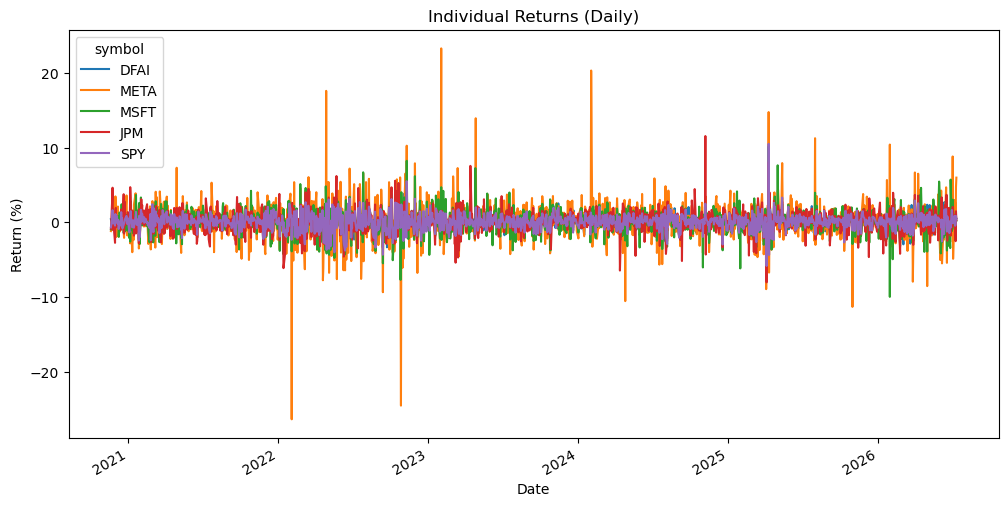

In [230]:
(p.returns(holding='all', log=False)*100).plot(
    title="Individual Returns (Daily)",
    xlabel="Date",
    ylabel="Return (%)",
    figsize=(12, 6)
)

<Axes: title={'center': 'Individual Returns (Cumulative)'}, xlabel='Date', ylabel='Cumulative Return (%)'>

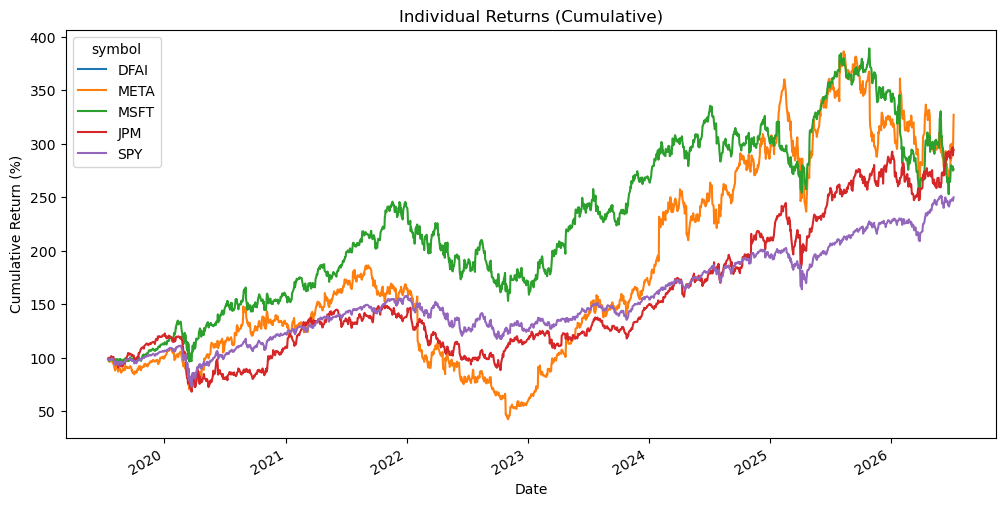

In [231]:
p.data.apply(lambda x: 100*x/x.iloc[0]-1).plot(
    title="Individual Returns (Cumulative)",
    xlabel="Date",
    ylabel="Cumulative Return (%)",
    figsize=(12, 6)
)

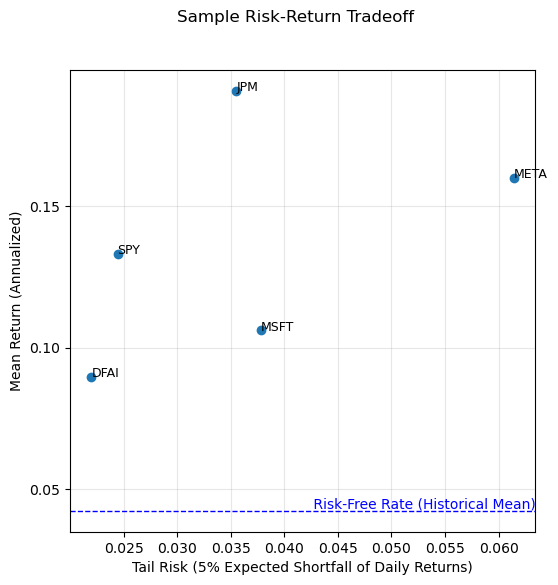

In [232]:
## make this plot a method in the class
fig, ax = plt.subplots(figsize=(6, 6))
x = -summary.loc['ES(5.0%)'] 
y = summary.loc['Mean (Ann.)']
ax.scatter(x=x, y=y)
texts = []
for col in summary.columns:
    texts.append(ax.text(x[col], y[col], col, fontsize=9))
ax.set_xlabel('Tail Risk (5% Expected Shortfall of Daily Returns)') ; ax.set_ylabel('Mean Return (Annualized)')
fig.suptitle(f'Sample Risk-Return Tradeoff')
ax.grid(True, alpha=0.3)
rf = 0.0425 # historical avg risk-free rate (10yr treasury YTM)
ax.axhline(y=rf, color='blue', linestyle='--', linewidth=1)
ax.text(
    ax.get_xlim()[1],
    rf,
    " Risk-Free Rate (Historical Mean)",
    color="blue",
    va="bottom",
    ha="right",
    fontsize=10
)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.05))

plt.show()


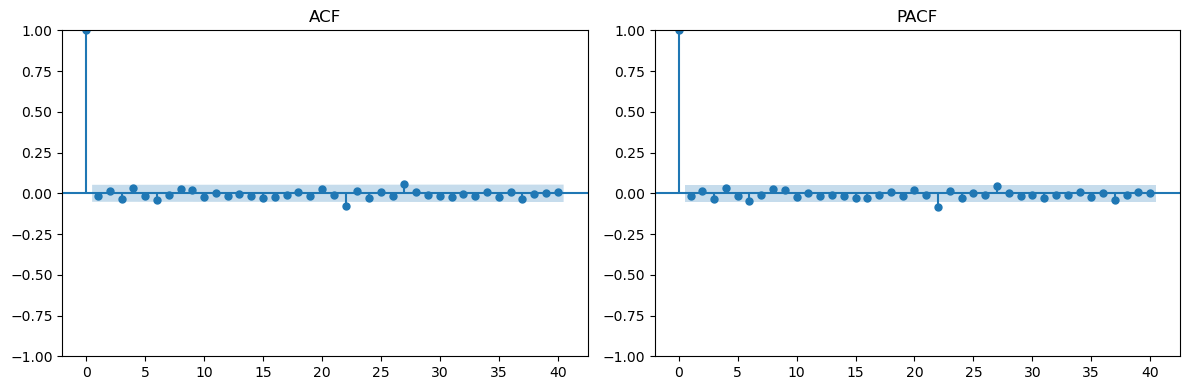

In [233]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# Plot ACF and PACF for returns
log_returns = p.returns(log=True).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(log_returns.iloc[:, 0], lags=40, ax=axes[0])
axes[0].set_title('ACF')

plot_pacf(log_returns.iloc[:, 0], lags=40, ax=axes[1])
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

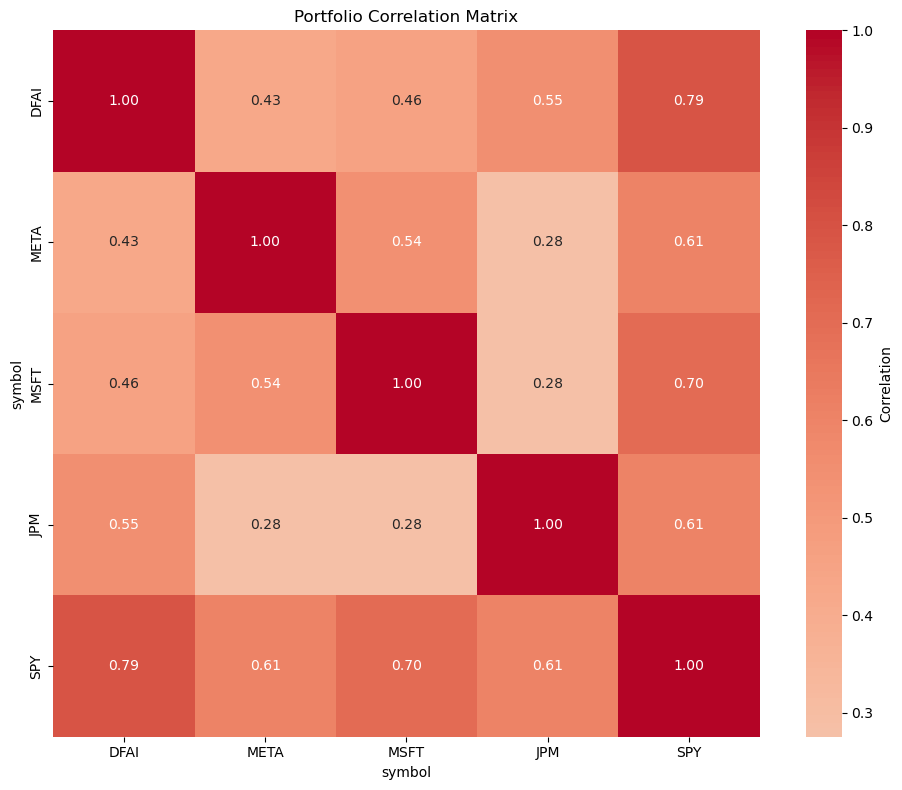

In [234]:
import seaborn as sns

corr_matrix = p.dependence()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Portfolio Correlation Matrix')
plt.tight_layout()
plt.show()

In [235]:
fit = p.copula_fit(criterion="aic") # note: this can take a couple minutes for the student-t copula

In [236]:
fit["summary"]

,family,loglik,n_params,aic,bic,params,error
0,student_t,2207.576019,11,-4393.152039,-4335.363865,"{'df': 6.142666826099258, 'rho': [0.4875897994...",None
1,gaussian,2032.229501,10,-4044.459001,-3991.924297,"{'rho': [0.47721354859184567, 0.45509093132546...",None


From Sklar's theorem, for a random $d$-vector $X=(X_1,\dots,X_d)^\top$ with joint CDF $F$, copula $C$, and margins $F_i$ for $X_i$, the CDF can be decomposed into
$$
F(x) = C\Big(F_1(x_1),\dots,F_d(x_d) \Big) \quad \forall x\in\mathbb{R}^d
$$
and hence the density $f$ satisfies
$$
f(x) = {\small \frac{d}{dx}} F(x) =  c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) \quad \forall x\in\mathbb{R}^d
$$
where $c$ is the density of the copula, i.e., 
$$ 
c(u) = {\small \frac{\partial^d}{\partial u_1 \cdots \partial u_d }} C(u)
$$

The $t$ copula with $\nu>0$ degrees of freedom and correlation matrix $P\in\mathbb{R}^{d\times d}$ can be represented by
$$
C^t_{\nu, P}(u) = \int_{-\infty}^{t^{-1}_\nu(u_1)} \cdots \int_{-\infty}^{t^{-1}_\nu(u_d)} \frac{\Gamma(\frac{\nu + d}{2})}{\Gamma(\nu/2) \sqrt{(\pi\nu)^d \det P}} 
\Big(1 + \frac{1}{\nu} x^\top P^{-1} x \Big)^{-(\nu + d)/{2}} dx \quad\quad \forall u\in(0,1)^d
$$
where $t^{-1}_\nu$ is the quantile function of a univariate $t_{(\nu)}$ distribution. 

Source: ("The $t$ Copula and Related Copulas") https://www.ressources-actuarielles.net/EXT/ISFA/1226.nsf/0/303eb11b4d617b79c1257b0800744575/$FILE/t%20copula%20demarta%20mcneil.pdf

Let $R=w^\top X$ be the portfolio return random variable, where $w\in[0,1]^d$ is the vector of (fixed) portfolio weights.

The CDF is of $R$ is then 
$$
\begin{aligned}
G(r) &= \mathbb{P}(R\leq r) = \int_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} f(x)dx = \int_{\mathbb{R}^d} \textbf{1}_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} f(x) dx \\
&= \int_{\mathbb{R}^d} \textbf{1}_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) dx
\end{aligned}
$$


In [237]:
simulate = p.joint_simulator()

$$
\text{ES}_\alpha(R)=\mathbb{E}[R\mid R \leq \text{VaR}_\alpha(R)]
$$

Monte Carlo estimate of ES(1.00%) is -3.48% with 95% CI: (-3.4817%, -3.4817%)
Standard Error of ES estimate: 0.000012%


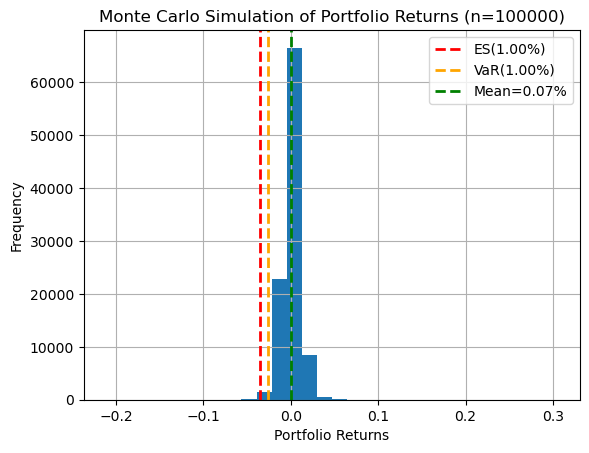

In [238]:
monte_carlo_es = p.monte_carlo_ES(n_samples=int(1e5), alpha=0.01)

- This is from *daily* returns. For monthly estimates, would need to use monthly data.

### `SimReturnsVector()`
1. Simulate $V\sim C$ via $V_i=C^{-1}(U_i)$ for $i=1,\dots,d$ where $U\overset{iid}{\sim}\text{Unif}(0,1)$
2. Simulate and return $X\sim F$ via $X_i=F_i^{-1}(V_i)$ for $i=1,\dots,d$

### `SimPortfolioReturn()`
1. Simulate $X=$`SimReturnsVector()`
2. Return $R=w^\top X$

### `SimShortfall()`
1. Simulate $R=$`SimPortfolioReturn()`
2. If $R\leq \text{VaR}_\alpha(R)$, (accept the sample) return $R$. Otherwise, return None (skip to next sample)

## Next Features for this Project
CAN DO NOW:
- fit margins to portfolio (already strated sketch of this method)
    - use margins + copula to (statically) estimate things like VaR and ES *for the portfolio random vector* $y=x^\top w$
    - TODO for this:
        - make joint_pdf() and joint_cdf method which creates the joint PDF and CDF using the margins and copula 
        - make risk_measures() method which uses the joint density to output key risk measures like ES, VaR, MaxDD, etc.
            - this will rely on portfolio weights (as opposed to individual security risks as prev done)
            - UP TO HERE COULD STAND ALONE AS A PARAMETRIC EQUITY RISK ENGINE BTW (?)

AFTER FINISHING MIT FACTOR MODELING STUDYING:
- linear factor models
    - understanding portfolio risks/drivers
    - parameter reduction for covariance estimation
    - stress testing (e.g. VaR / ES under different macro shock/equity market scenarios)
- portfolio optimization
    - Mean-Var optimiziation (with different covariance matrix estimates incl. the factor model est.)
    - Mean-ES optimization
- volatility models
    - GARCH (+ dynamic mean return model -- look for examples online of what ppl use / look at Mike M's PhD paper)
    - Stochastic Vol model (Heston) - which also models returns as a whole
    - VaR / ES forecasting from the model
- genAI feature(s): 
    - RAG over market news for explaining recent portfolio movements

SEPARATE PROJECT:
- market bubble / market crash predictor
    - can try a variety of methods and/or an ensemble of them
        - the graph theory one or whatever from algebraic continuation channel,
        - the XLU/SPY z-score thiing or whatever from iPhone notes on PROJECTS

### Next: do ES-based portfolio optimization (e.g. using `cvxpy`) and test out/make portfolio-wide summaries

- Review portfolio optimization math
    - CS 335 chapter 
    - ACTSC 372 chapter 
    - CO 372

Need to use weights not quantities. Also, we have to make an assumption about dynamic rebalancing right?

### Some Plotting (make this a method)

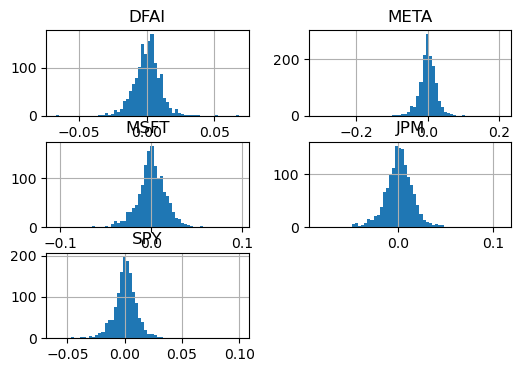

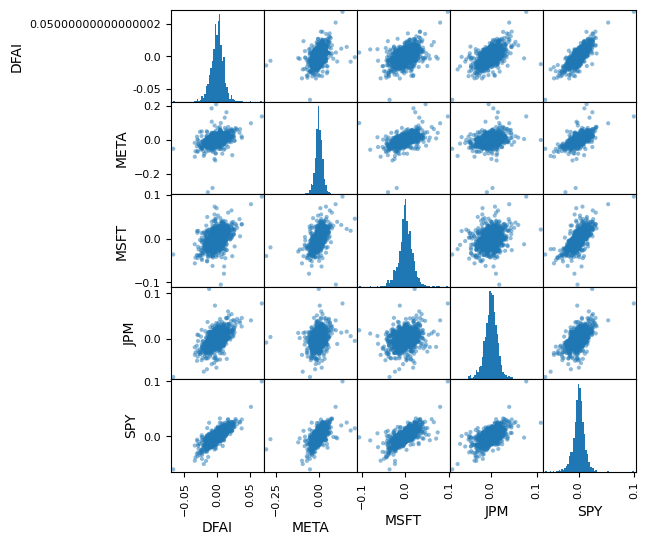

In [239]:
# histogram of returns of each holding
log_returns = p.returns(log=True)
log_returns.hist(bins=60, figsize=(6,4))
plt.show()

# scatterplot matrix of portfolio returns
pd.plotting.scatter_matrix(log_returns, figsize=(6,6), hist_kwds={'bins':60})
plt.show()